In [1]:
from google.colab import drive
drive.mount = '/content/AI-Generated Scientific Text Dataset (AIGTxt).xlsx'


In [2]:
import pandas as pd

file_path = '/content/AI-Generated Scientific Text Dataset (AIGTxt).xlsx'
df = pd.read_excel(file_path)

df = df[['Human-Generated', 'ChatGPT-Generated']]


In [3]:
df.head()

,Human-Generated,ChatGPT-Generated
0,Photo-realistic image rendering using standard...,Achieving photo-realistic image rendering thro...
1,The Large Hadron Collider is exploring physics...,The Large Hadron Collider (LHC) serves as a fr...
2,With the rapid development of mobile Internet ...,In the era of swift advancements in mobile Int...
3,Most contour tracking methods can be grouped i...,Contour tracking methods can be broadly catego...
4,Year 2010 is regarded as the breakthrough year...,The pivotal year 2010 marked a significant bre...


In [25]:
import re

def preprocess_scientific_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r'\[\d+(?:,\s*\d+)*\]', '', text)
    text = re.sub(r'\[\d+-\d+\]', '', text)
    text = re.sub(r'\([A-Z][a-z]+, \d{4}\)', '', text)
    text = text.replace('\n', ' ').replace('\r', ' ')
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [5]:
df['Human-Generated'] = df['Human-Generated'].apply(preprocess_scientific_text)
df['ChatGPT-Generated'] = df['ChatGPT-Generated'].apply(preprocess_scientific_text)

In [24]:
df = df[(df['Human-Generated'] != "") & (df['ChatGPT-Generated'] != "")]

human_texts = df['Human-Generated'].tolist()
ai_texts = df['ChatGPT-Generated'].tolist()

texts = human_texts + ai_texts
labels = [0] * len(human_texts) + [1] * len(ai_texts)

print("--- HUMAN GENERATED (Label 0) ---")
for i in range(3):
    print(f"Label: {labels[i]} | Text: {texts[i][:100]}...")

print("\n--- AI GENERATED (Label 1) ---")
start_ai = len(human_texts)
for i in range(start_ai, start_ai + 3):
    print(f"Label: {labels[i]} | Text: {texts[i][:100]}...")

--- HUMAN GENERATED (Label 0) ---
Label: 0 | Text: Photo-realistic image rendering using standard graphics techniques is involved, since geometry, mate...
Label: 0 | Text: The Large Hadron Collider is exploring physics at the energy frontier, probing some of the most fund...
Label: 0 | Text: With the rapid development of mobile Internet technology, more and more image information is stored ...

--- AI GENERATED (Label 1) ---
Label: 1 | Text: Achieving photo-realistic image rendering through conventional graphics techniques necessitates expl...
Label: 1 | Text: The Large Hadron Collider (LHC) serves as a frontier for exploring high-energy physics, delving into...
Label: 1 | Text: In the era of swift advancements in mobile Internet technology, a burgeoning volume of image data is...


In [8]:
!pip -q install "transformers>=4.41.0" "datasets>=2.20.0" "accelerate>=0.34.0" scikit-learn

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Preprocessing complete. Total samples: {len(texts)}")

Preprocessing complete. Total samples: 7214


In [15]:
from transformers import BertTokenizer, BertModel
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained("bert-base-uncased")
text = "Replace me by any text you'd like."
encoded_input = tokenizer(text, return_tensors='pt')
output = model(**encoded_input)

In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def encode_data(text_list, label_list):
    encodings = tokenizer(text_list, padding=True, truncation=True, max_length=256, return_tensors="pt")
    return TensorDataset(encodings['input_ids'], encodings['attention_mask'], torch.tensor(label_list))

train_loader = DataLoader(encode_data(train_texts, train_labels), batch_size=16, shuffle=True)
val_loader = DataLoader(encode_data(val_texts, val_labels), batch_size=16)

In [21]:
# MODEL TRAINING

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

print(f"Starting training on {device}...")
for epoch in range(3):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        b_input_ids, b_attn_mask, b_labels = [t.to(device) for t in batch]
        outputs = model(b_input_ids, attention_mask=b_attn_mask, labels=b_labels)
        outputs.loss.backward()
        optimizer.step()
        total_loss += outputs.loss.item()
    print(f"Epoch {epoch+1} | Avg Train Loss: {total_loss/len(train_loader):.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training on cuda...
Epoch 1 | Avg Train Loss: 0.2463
Epoch 2 | Avg Train Loss: 0.0921
Epoch 3 | Avg Train Loss: 0.0596


In [22]:
print("\nEvaluating model performance...")
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for batch in val_loader:
        b_input_ids, b_attn_mask, b_labels = [t.to(device) for t in batch]
        outputs = model(b_input_ids, attention_mask=b_attn_mask)
        preds = torch.argmax(outputs.logits, dim=1).flatten().cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(b_labels.cpu().numpy())

target_names = ['Human-Written', 'AI-Generated']
print("\n--- Final Metrics ---")
print(classification_report(all_true, all_preds, target_names=target_names))


Evaluating model performance...

--- Final Metrics ---
               precision    recall  f1-score   support

Human-Written       0.97      0.95      0.96       722
 AI-Generated       0.95      0.97      0.96       721

     accuracy                           0.96      1443
    macro avg       0.96      0.96      0.96      1443
 weighted avg       0.96      0.96      0.96      1443



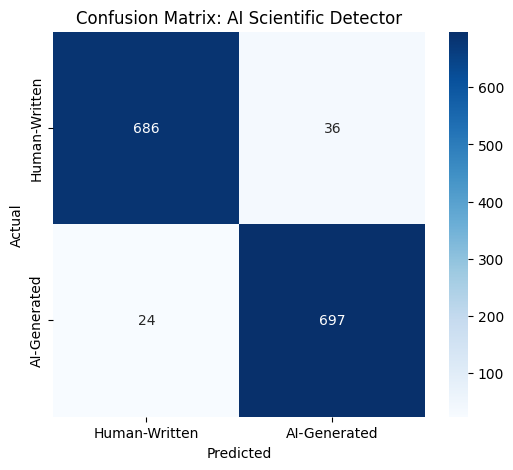

In [27]:
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: AI Scientific Detector')
plt.show()